In [13]:
import vireoSNP
from vireoSNP import BinomMixtureVB
from vireoSNP.plot.base_plot import heat_matrix
import numpy as np
from scipy import sparse
from scipy.io import mmread
import matplotlib.pyplot as plt
import pandas as pd

print(vireoSNP.__version__)

0.5.9


In [2]:
# Assign clones with vireoSNP
# Here we assign cells to clones based on mtDNA mutations found by MQuad. Although there are only 2 variants found due to sparsity of 10x dataset, vireo still confidently assigns a good proportion of cells into 2 clones.

# read in output from MQuad

AD = mmread("../../../results/standalone/mquad/TNBC1/passed_ad.mtx").tocsc()
DP = mmread("../../../results/standalone/mquad/TNBC1/passed_dp.mtx").tocsc()

AD.shape, DP.shape

((2, 1097), (2, 1097))

In [3]:
# we have already run the estimate of the number of donors at this point and we fix it
_model = BinomMixtureVB(n_var=len(AD.getnnz(axis=1)), n_cell=len(AD.getnnz(axis=0)), n_donor=3)
_model.fit(AD, DP, min_iter=30, n_init=300)

# save the object
modelCA = _model

In [4]:
# the ID_prob slot holds the probability of being either one of the n_donor fixed
for i in modelCA.ID_prob:
    print(i)

[2.56656584e-01 7.43342167e-01 1.24937360e-06]
[0.49504534 0.50094149 0.00401317]
[3.29752260e-01 6.70161559e-01 8.61809541e-05]
[0.43240525 0.51637417 0.05122058]
[6.72633676e-01 3.27365936e-01 3.88573069e-07]
[4.05452791e-01 5.94547140e-01 6.83401741e-08]
[0.71026011 0.28427225 0.00546763]
[2.65757313e-01 7.34242686e-01 4.86659805e-10]
[0.43240525 0.51637417 0.05122058]
[2.10303425e-12 5.21564508e-16 1.00000000e+00]
[2.2500952e-01 7.7498977e-01 7.0982300e-07]
[1.97443958e-01 8.02546941e-01 9.10132023e-06]
[0.55498812 0.44425835 0.00075353]
[0.67608946 0.32246853 0.00144201]
[3.65906694e-01 6.34092795e-01 5.11445012e-07]
[3.28088338e-01 6.71907860e-01 3.80287625e-06]
[4.05788597e-01 5.94211282e-01 1.20518632e-07]
[2.99301215e-01 7.00698785e-01 3.75091618e-11]
[0.43013174 0.43133171 0.13853655]
[0.49504534 0.50094149 0.00401317]
[6.66160562e-01 3.33839438e-01 2.62351235e-12]
[0.49504534 0.50094149 0.00401317]
[8.85523842e-01 1.14476158e-01 3.74032105e-14]
[3.63003108e-01 6.36996889e-01

In [16]:
for i in modelCA.ELBO_inits:
    print(i)

-1920.182274942582
-1920.1823909815212
-1920.1822709277903
-1920.182645836529
-1920.1824783392008
-1920.1828877107905
-1920.1827217729838
-1920.1826183880348
-1920.1822634838754
-1920.1824719870838
-1920.1823035504935
-1920.1822634257965
-1920.1823133257767
-1920.1824351154114
-1920.1822650135368
-1920.1822650425606
-1920.1891007859776
-1920.1823809959187
-1920.1825083131557
-1920.1822829576122
-1920.1823308306184
-1920.1827331832023
-1920.2078679764854
-1920.182332486424
-1920.1832326982126
-1920.1837996684512
-1920.182484286624
-1920.1833005123895
-1920.1836824605648
-1920.1831498970878
-1920.182271585537
-1920.1835065595355
-1920.1822970533453
-1920.1830611105247
-1920.1822736198774
-1920.1822934096203
-1920.1874615879228
-1920.1825094326668
-1920.2142378411381
-1920.1828619876055
-1920.1822850847557
-1920.1822997006784
-1920.1822636543811
-1920.1829450342739
-1920.182811298815
-1920.1860866566053
-1920.1828427140304
-1920.183099892538
-1920.2069341810193
-1920.1839174602574
-1920.1

In [ ]:
# table for the allelic ratio per variant per clone id
for i in modelCA.beta_mu:
    print(i)

[0.00097652 0.00028051 0.24731804]
[0.23702374 0.0939686  0.12866586]


In [ ]:
modelCA

AttributeError: 'BinomMixtureVB' object has no attribute '__annotations__'

In [5]:
# load the ordered barcodes from the cells this should be equivalent to the input of cellsnp
with open('../../../../data/aaronkwc-MQuad_paper_reproduced_results-d9de94f/droplet_based_data/TNBC1_data/cellsnp/cellSNP.samples.tsv', 'r') as f:
    sample_id = f.read().splitlines()

In [6]:
# laod the barcode annotation in present/needed
with open('../../../../data/aaronkwc-MQuad_paper_reproduced_results-d9de94f/droplet_based_data/TNBC1_data/tumor_label.txt', 'r') as f:
    tumor = f.read().splitlines()

In [7]:
# for each ID_prop avaluate which one is the most likely and assigni the barcode
conf = []
for i in modelCA.ID_prob:
    if max(i) >= 0.8:
        conf.append('True')
    else:
        conf.append('False')
        
clone_id = np.argmax(modelCA.ID_prob, axis=1)

In [8]:
clone_id

array([1, 1, 1, ..., 0, 1, 0], shape=(1097,))

In [ ]:
# define the final metadata with all the info available
clones_df = pd.DataFrame(data={'sample_id':sample_id, 'clone_id':clone_id, 'confident':conf,'tumor':tumor})
clones_df = clones_df.rename({0: 'sample_id', 1: 'clone_id', 2:'confident', 3:'tumor'}, axis='columns')
clones_df

,sample_id,clone_id,confident,tumor
0,AAACCTGCACCTTGTC-1,1,False,T
1,AAACGGGAGTCCTCCT-1,1,False,N
2,AAACGGGTCCAGAGGA-1,1,False,T
3,AAAGATGCAGTTTACG-1,1,False,T
4,AAAGCAACAGGAATGC-1,0,False,T
...,...,...,...,...
1092,TTTATGCTCCTCATTA-1,1,True,T
1093,TTTATGCTCTGTTGAG-1,1,False,T
1094,TTTCCTCTCGGAAACG-1,0,False,T
1095,TTTGCGCCAATCACAC-1,1,False,T


In [10]:
# save clone_id for later use
clones_df.to_csv('../../../../data/MQuad_test/TNBC1/clones_df.csv')

In [ ]:
# plotting
def plot_figure_5b_assignment(modelCA):
    im = heat_matrix(modelCA.ID_prob, cmap="Oranges", alpha=0.8,
                 display_value=False, row_sort=True, interpolation = 'none')
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.title("Assignment probability")
    plt.xlabel("Clone")
    plt.ylabel("%d cells" %(modelCA.n_cell))
    plt.xticks(range(modelCA.n_donor))
    plt.tight_layout()

def plot_figure_5b_AF(modelCA):
    im = heat_matrix(modelCA.beta_mu, cmap="Blues", alpha=0.8, 
                 display_value=False, row_sort=True, interpolation='none')
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.title("Mean allelic ratio")
    plt.xlabel("Clone")
    plt.ylabel("%d SNPs" %(modelCA.n_var))
    plt.xticks(range(modelCA.n_donor))
    plt.tight_layout()

KeyError: 'copykat'

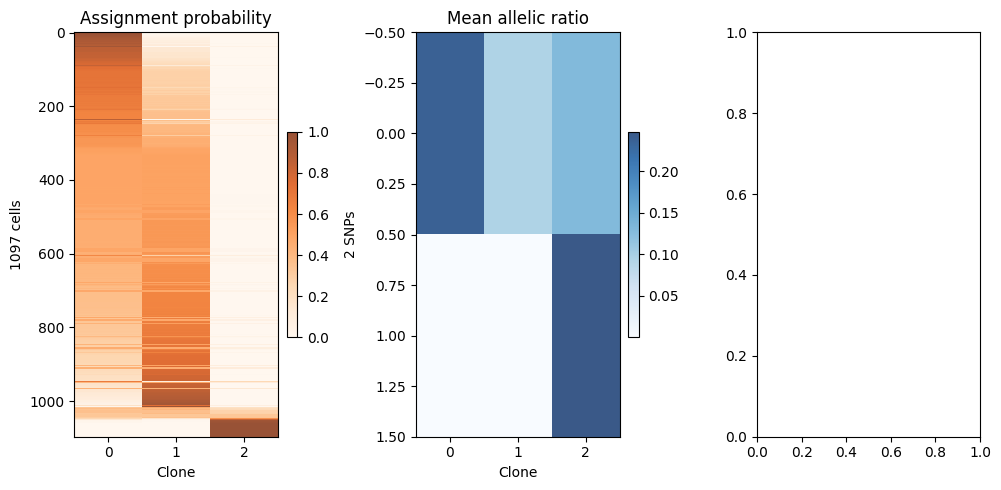

In [15]:
fig = plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plot_figure_5b_assignment(modelCA)

plt.subplot(1,3,2)
plot_figure_5b_AF(modelCA)

ax=plt.subplot(1,3,3)
plot_figure_5c(ax)